LAB 5.1 You have done segmentation of EO images based on land-cover (man-made, forests, ocean). Take some patches of similar types of land-cover. Then, use PCA to reduce the dimension of the data into three so that you can visualise the data. Now, see if the data from the various land-covers cluster in PC-dimensions.

In [1]:
import ee
ee.Initialize(project='ee-jsumara')

In [2]:

import geemap
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D 

In [3]:
aoi = ee.Geometry.Rectangle([18.60, 54.34, 18.76, 54.42])
bands = ["B2", "B3", "B4", "B8", "B11"] 


s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate("2022-06-01", "2022-08-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 10))
    .median()
    .clip(aoi)
    .select(bands)
)

m = geemap.Map(center=[54.35, 18.65], zoom=10)
m.addLayer(s2, {"bands": ["B4", "B3", "B2"], "min": 0, "max": 3000}, "S2 RGB")
m.addLayer(aoi, {}, "AOI")
m

Map(center=[54.35, 18.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [4]:
# WorldCover classes (common):
# 10 = Tree cover, 50 = Built-up, 80 = Permanent water bodies
wc = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").clip(aoi)

In [5]:
# simplified mask
labels = (
    ee.Image(0).where(wc.eq(50), 0)
              .where(wc.eq(10), 1)
              .where(wc.eq(80), 2)
)

valid_mask = wc.eq(50).Or(wc.eq(10)).Or(wc.eq(80))
labels = labels.updateMask(valid_mask)

m2 = geemap.Map(center=[54.35, 18.65], zoom=10)
m2.addLayer(wc, {"min": 0, "max": 100}, "WorldCover (raw)")
m2.addLayer(labels, {"min": 0, "max": 2}, "Labels (0 built / 1 forest / 2 water)")
m2


Map(center=[54.35, 18.65], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [6]:
scale = 20

stack = s2.addBands(labels.rename("label"))
data = geemap.ee_to_numpy(stack, region=aoi, scale=scale)
img = data[:, :, :len(bands)].astype(np.float32)
mask = data[:, :, len(bands)].astype(np.int32)

print("img shape (H, W, B):", img.shape)
print("mask shape (H, W):", mask.shape)
print("Unique labels:", np.unique(mask[~np.isnan(mask)]))

valid = ~np.isnan(mask)
mask = np.where(valid, mask, -1).astype(np.int32)

img shape (H, W, B): (446, 891, 5)
mask shape (H, W): (446, 891)
Unique labels: [0 1 2]


In [7]:
valid = mask >= 0
vals, counts = np.unique(mask[valid], return_counts=True)
print("Class pixel counts:", dict(zip(vals, counts)))
print("Class proportions:", dict(zip(vals, counts / counts.sum())))


Class pixel counts: {0: 185139, 1: 91283, 2: 120964}
Class proportions: {0: 0.4658921049055578, 1: 0.22970864600162058, 2: 0.30439924909282157}


In [8]:
def sample_patches_mean_spectrum(img, mask, class_id, patch_size=16, n_patches=200, purity=0.85, seed=0):
    rng = np.random.default_rng(seed)
    H, W, B = img.shape
    r = patch_size // 2

    ys, xs = np.where(mask == class_id)
    ok = (ys >= r) & (ys < H - r) & (xs >= r) & (xs < W - r)
    ys, xs = ys[ok], xs[ok]

    feats = []
    tries, max_tries = 0, n_patches * 100

    while len(feats) < n_patches and tries < max_tries and len(xs) > 0:
        tries += 1
        i = rng.integers(0, len(xs))
        cy, cx = ys[i], xs[i]

        pm = mask[cy - r: cy + r, cx - r: cx + r]
        if np.mean(pm == class_id) >= purity:
            patch = img[cy - r: cy + r, cx - r: cx + r, :]
            feat = patch.reshape(-1, B).mean(axis=0)
            feats.append(feat)

    return np.array(feats)

class_map = {0: "man-made", 1: "forest", 2: "ocean/water"}

patch_size = 16
n_patches = 250

X_list, y_list = [], []
for cid, name in class_map.items():
    feats = sample_patches_mean_spectrum(
        img, mask, cid,
        patch_size=patch_size,
        n_patches=n_patches,
        purity=0.85,
        seed=100 + cid
    )
    print(f"{name}: {len(feats)} patches")
    if len(feats) > 0:
        X_list.append(feats)
        y_list.append(np.full(len(feats), cid))

X = np.vstack(X_list)
y = np.concatenate(y_list)

print("Final feature matrix X:", X.shape)


man-made: 250 patches
forest: 250 patches
ocean/water: 250 patches
Final feature matrix X: (750, 5)


Explained variance ratio: [0.7706914  0.22150101 0.00635987]
Total (3 PCs): 0.99855226


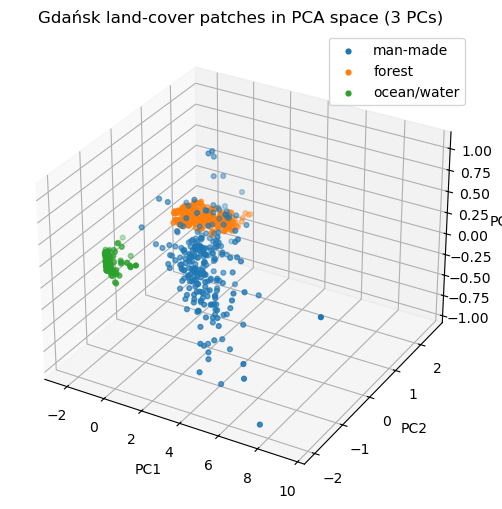

In [9]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D 

# Standardize (important for PCA)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=3, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total (3 PCs):", pca.explained_variance_ratio_.sum())

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

for cid, name in class_map.items():
    pts = X_pca[y == cid]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=12, label=name)

ax.set_title("Gdańsk land-cover patches in PCA space (3 PCs)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()


A Sentinel-2 multispectral image covering the central part of Gdańsk and the adjacent Baltic Sea was used. Five spectral bands were selected (B2 – Blue, B3 – Green, B4 – Red, B8 – NIR, B11 – SWIR).
Based on the ESA WorldCover dataset, three land-cover classes were considered: man-made, forest, and ocean/water.

From the image, small patches representing homogeneous land-cover were extracted. For each class, 250 “pure” patches were selected, where at least 85% of the pixels belonged to the same land-cover type. Each patch was represented by its mean spectral signature, resulting in a 5-dimensional feature vector.

Before applying PCA, the feature vectors were standardised. PCA was then used to reduce the dimensionality of the data from five spectral dimensions to three principal components in order to enable visualisation.

The explained variance ratios were:
PC1: 77.1%
PC2: 22.2%
PC3: 0.6%

In total, the first three principal components explain 99.86% of the variance, which indicates that almost all spectral information is preserved in the reduced space.

The 3D PCA scatter plot shows a clear separation between the land-cover classes.
Ocean/water patches form a very compact and well-separated cluster, mainly along the first principal component. This reflects the relatively uniform spectral characteristics of water surfaces.
Forest patches appear as a distinct cluster, separated from water and partially separated from man-made areas. This separation is primarily driven by the vegetation response in the near-infrared band.
Man-made patches show the largest spread in PCA space. This is expected due to the heterogeneity of urban surfaces, such as buildings, roads, industrial areas, and shadows.

The limited overlap between forest and man-made patches suggests that, although some spectral similarity exists, the land-cover types remain distinguishable using linear components.

LAB 5.2 Use any EO-image you can get hold of. Try to use the auto encoder codes shared with you for super-resolution. Apply that on the EO-image you have chosen. Does it enhance the resolution? How can you make it work better?

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model


HR RGB: (446, 891, 3) 0.016 1.0


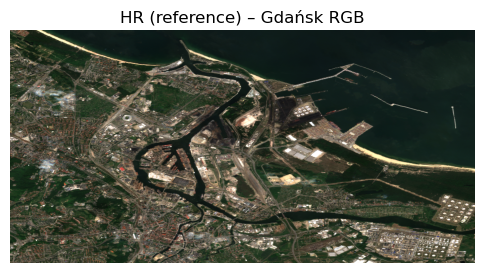

In [12]:
hr = img[:, :, [2, 1, 0]].astype(np.float32)  

hr = np.clip(hr / 3000.0, 0, 1)

print("HR RGB:", hr.shape, hr.min(), hr.max())

plt.figure(figsize=(6,6))
plt.imshow(hr)
plt.title("HR (reference) – Gdańsk RGB")
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015697384..1.0900451].


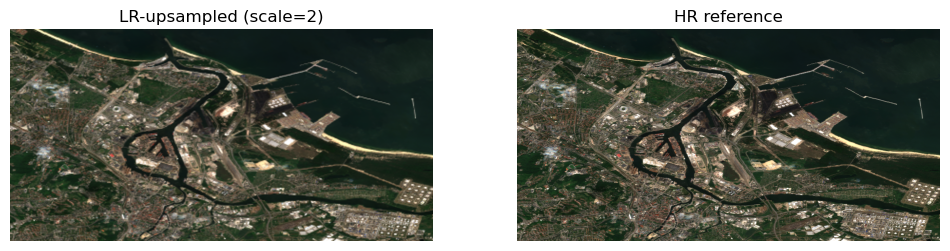

In [13]:
def make_lr_from_hr(hr_img, scale=2):
    """Downsample then upsample back to original size."""
    H, W, C = hr_img.shape
    # Downsample
    lr_small = tf.image.resize(hr_img, (H // scale, W // scale), method="area")
    # Upsample back
    lr_up = tf.image.resize(lr_small, (H, W), method="bicubic")
    return lr_up.numpy()

scale = 2
lr_up = make_lr_from_hr(hr, scale=scale)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(lr_up); plt.title(f"LR-upsampled (scale={scale})"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(hr); plt.title("HR reference"); plt.axis("off")
plt.show()


In [14]:
def extract_patches(lr_img, hr_img, patch=48, stride=24):
    H, W, C = hr_img.shape
    X, Y = [], []
    for y in range(0, H - patch + 1, stride):
        for x in range(0, W - patch + 1, stride):
            X.append(lr_img[y:y+patch, x:x+patch, :])
            Y.append(hr_img[y:y+patch, x:x+patch, :])
    return np.stack(X), np.stack(Y)

X, Y = extract_patches(lr_up, hr, patch=48, stride=24)
print("Training patches:", X.shape, Y.shape)

# Shuffle
idx = np.random.permutation(len(X))
X, Y = X[idx], Y[idx]

# Split
n = len(X)
n_train = int(0.9 * n)
X_train, Y_train = X[:n_train], Y[:n_train]
X_val, Y_val = X[n_train:], Y[n_train:]


Training patches: (612, 48, 48, 3) (612, 48, 48, 3)


In [15]:
def build_sr_autoencoder(input_shape=(48,48,3)):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(inp)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)

    # "Bottleneck" (autoencoder feel)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)

    # Reconstruction
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    out = layers.Conv2D(3, 3, padding="same", activation="sigmoid")(x)

    return Model(inp, out)

model = build_sr_autoencoder((48,48,3))
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,659 (338.51 KB)

 Trainable params: 86,659 (338.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 340ms/step - loss: 0.2256 - val_loss: 0.1764
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 314ms/step - loss: 0.1240 - val_loss: 0.0778
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 409ms/step - loss: 0.0729 - val_loss: 0.0620
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 390ms/step - loss: 0.0559 - val_loss: 0.0470
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 394ms/step - loss: 0.0456 - val_loss: 0.0462
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 462ms/step - loss: 0.0427 - val_loss: 0.0462
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 357ms/step - loss: 0.0401 - val_loss: 0.0384
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 388ms/step - loss: 0.0373 - val_loss: 0.0391
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 332ms/step - loss: 0.0374 - val_loss: 0.0368
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 424ms/step - loss: 0.0355 - val_loss: 0.0356


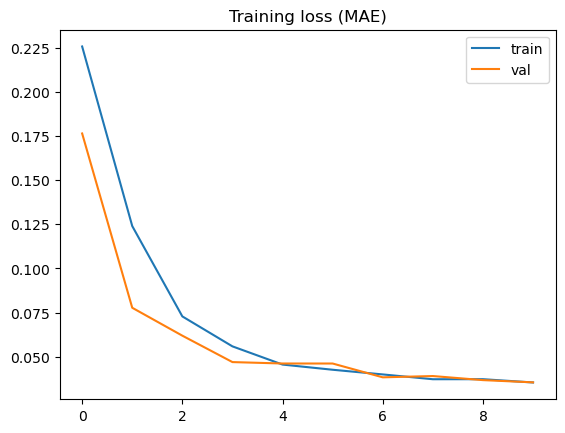

In [16]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=32,
    verbose=1
)

plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Training loss (MAE)")
plt.legend()
plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015697384..1.0900451].


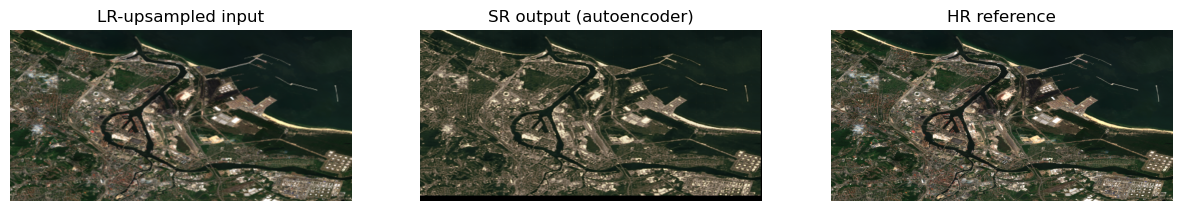

In [17]:
def predict_full_image(model, lr_img, patch=48, stride=24):
    H, W, C = lr_img.shape
    out = np.zeros_like(lr_img, dtype=np.float32)
    wgt = np.zeros((H, W, 1), dtype=np.float32)

    for y in range(0, H - patch + 1, stride):
        for x in range(0, W - patch + 1, stride):
            inp = lr_img[y:y+patch, x:x+patch, :][None, ...]
            pred = model.predict(inp, verbose=0)[0]
            out[y:y+patch, x:x+patch, :] += pred
            wgt[y:y+patch, x:x+patch, :] += 1.0

    out = out / np.maximum(wgt, 1e-6)
    return np.clip(out, 0, 1)

sr = predict_full_image(model, lr_up, patch=48, stride=24)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(lr_up); plt.title("LR-upsampled input"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(sr); plt.title("SR output (autoencoder)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(hr); plt.title("HR reference"); plt.axis("off")
plt.show()


In [18]:
def psnr(a, b):
    mse = np.mean((a - b)**2)
    if mse == 0:
        return 99.0
    return 10 * np.log10(1.0 / mse)

print("PSNR(LR-up vs HR):", psnr(lr_up, hr))
print("PSNR(SR vs HR):   ", psnr(sr, hr))


PSNR(LR-up vs HR): 25.235403823119128
PSNR(SR vs HR):    22.044763132499014


The conducted experiment demonstrates that a convolutional autoencoder can be applied to Earth observation imagery for super-resolution tasks, but its effectiveness is limited. Although the network converged properly during training and produced visually plausible results, the super-resolved image did not outperform simple bicubic upsampling in terms of quantitative quality metrics such as PSNR. The autoencoder mainly learned to smooth and regularise the input image rather than reconstruct fine spatial details, which is particularly noticeable in complex urban areas. As a result, the perceived visual improvement does not correspond to a true enhancement of spatial resolution. These findings indicate that basic autoencoder architectures are insufficient for high-quality super-resolution of EO data, and that more advanced models, loss functions, and training strategies are required to achieve meaningful improvements.